=== Simple Linear Regression ===
Coefficient: 2.0500
Intercept: 2.9900
R² Score: 0.9994
MSE: 0.0054



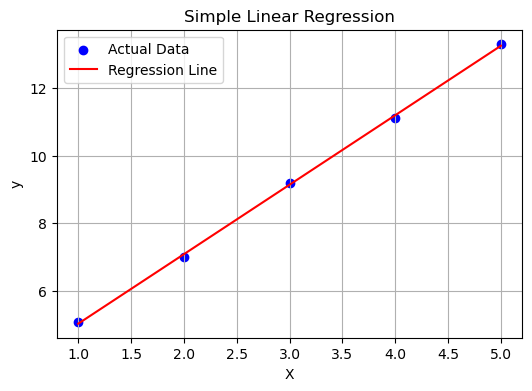

=== Multiple Linear Regression (Custom Data) ===
Coefficients: [1.98333333 2.08333333]
Intercept: 2.9400
R² Score: 1.0000
MSE: 0.0004



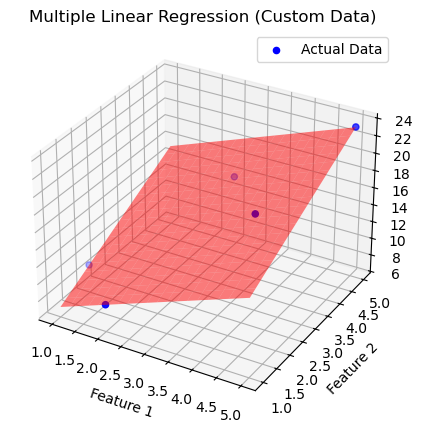

=== Multiple Linear Regression (Diabetes Dataset) ===
Coefficients: [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
Intercept: 151.3456
R² Score (Test): 0.4526
MSE (Test): 2900.1936


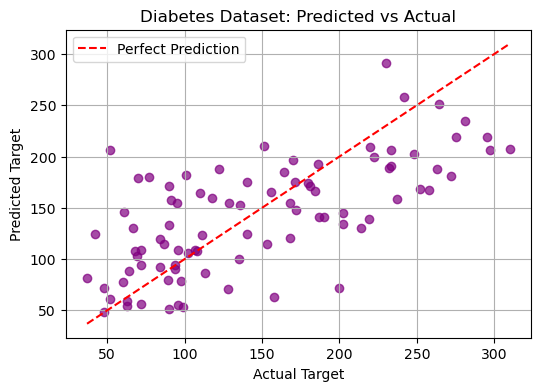

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. SIMPLE LINEAR REGRESSION 

X_simple = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y_simple = np.array([5.1, 7.0, 9.2, 11.1, 13.3])

simple_model = LinearRegression()
simple_model.fit(X_simple, y_simple)
y_simple_pred = simple_model.predict(X_simple)

print("=== Simple Linear Regression ===")
print(f"Coefficient: {simple_model.coef_[0]:.4f}")
print(f"Intercept: {simple_model.intercept_:.4f}")
print(f"R² Score: {r2_score(y_simple, y_simple_pred):.4f}")
print(f"MSE: {mean_squared_error(y_simple, y_simple_pred):.4f}\n")

# Visualization
plt.figure(figsize=(6, 4))
plt.scatter(X_simple, y_simple, color='blue', label='Actual Data')
plt.plot(X_simple, y_simple_pred, color='red', label='Regression Line')
plt.title("Simple Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# 2. MULTIPLE LINEAR REGRESSION
X_multi = np.array([
    [1, 2],
    [2, 1],
    [3, 4],
    [4, 3],
    [5, 5]
])
y_multi = np.array([9.1, 9.0, 17.2, 17.1, 23.3])

multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)
y_multi_pred = multi_model.predict(X_multi)

print("=== Multiple Linear Regression (Custom Data) ===")
print(f"Coefficients: {multi_model.coef_}")
print(f"Intercept: {multi_model.intercept_:.4f}")
print(f"R² Score: {r2_score(y_multi, y_multi_pred):.4f}")
print(f"MSE: {mean_squared_error(y_multi, y_multi_pred):.4f}\n")

# Visualization (3D)
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_multi[:, 0], X_multi[:, 1], y_multi, color='blue', label='Actual Data')

# Create grid for regression plane
x_surf, y_surf = np.meshgrid(
    np.linspace(X_multi[:, 0].min(), X_multi[:, 0].max(), 20),
    np.linspace(X_multi[:, 1].min(), X_multi[:, 1].max(), 20)
)
z_surf = (multi_model.intercept_ +
          multi_model.coef_[0] * x_surf +
          multi_model.coef_[1] * y_surf)

ax.plot_surface(x_surf, y_surf, z_surf, color='red', alpha=0.5)
ax.set_title("Multiple Linear Regression (Custom Data)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Target")
plt.legend()
plt.show()

# 3. MULTIPLE LINEAR REGRESSION (Diabetes Dataset)

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

diabetes_model = LinearRegression()
diabetes_model.fit(X_train, y_train)
y_pred = diabetes_model.predict(X_test)

print("=== Multiple Linear Regression (Diabetes Dataset) ===")
print(f"Coefficients: {diabetes_model.coef_}")
print(f"Intercept: {diabetes_model.intercept_:.4f}")
print(f"R² Score (Test): {r2_score(y_test, y_pred):.4f}")
print(f"MSE (Test): {mean_squared_error(y_test, y_pred):.4f}")

# Visualization: Predicted vs Actual
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, color='purple', alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect Prediction')
plt.title("Diabetes Dataset: Predicted vs Actual")
plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.legend()
plt.grid(True)
plt.show()
